In [122]:
## 306 project
#install.packages("dplyr")
library(dplyr)
#install.packages("ggplot2")
library(ggplot2)
#install.packages("tidyverse")
library(tidyverse)
library(patchwork)

In [123]:
# Load Data
yield_data <- read.csv("cereal-crop-yield-vs-fertilizer-application.csv")
co_data    <- read.csv("co-emissions-per-capita.csv")
gdp_data   <- read.csv("gdp-per-capita-worldbank.csv")

In [124]:
# Clean data and organize into one data frame
avg_yield <- yield_data %>%
  filter(Year >= 2019) %>%
  group_by(Entity, region = World.region.according.to.OWID) %>%
  summarise(mean_yield = mean(Cereal.yield, na.rm = TRUE), .groups = "drop")

avg_co <- co_data %>%
  filter(Year >= 2019) %>%
  group_by(Entity) %>%
  summarise(mean_co = mean(CO..emissions.per.capita, na.rm = TRUE), .groups = "drop")

avg_gdp <- gdp_data %>%
  filter(Year >= 2019) %>%
  group_by(Entity) %>%
  summarise(mean_gdp = mean(GDP.per.capita, na.rm = TRUE), .groups = "drop")

model_df <- avg_yield %>%
  inner_join(avg_co, by = "Entity") %>%
  inner_join(avg_gdp, by = "Entity") %>%
  filter(!is.na(region)) %>%
 filter(mean_yield > 0, mean_co > 0, mean_gdp > 0, region != "")


In [125]:
# 3. Summary Statistic
summary(model_df)
table(model_df$region)

    Entity             region            mean_yield          mean_co        
 Length:170         Length:170         Min.   : 0.02167   Min.   : 0.04994  
 Class :character   Class :character   1st Qu.: 1.65163   1st Qu.: 0.75359  
 Mode  :character   Mode  :character   Median : 3.20280   Median : 2.53943  
                                       Mean   : 3.80317   Mean   : 4.29831  
                                       3rd Qu.: 5.04743   3rd Qu.: 5.62626  
                                       Max.   :24.27842   Max.   :38.12798  
    mean_gdp     
 Min.   :  1040  
 1st Qu.:  5618  
 Median : 15572  
 Mean   : 23688  
 3rd Qu.: 35197  
 Max.   :131743  


       Africa          Asia        Europe North America       Oceania 
           50            43            39            20             7 
South America 
           11 

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


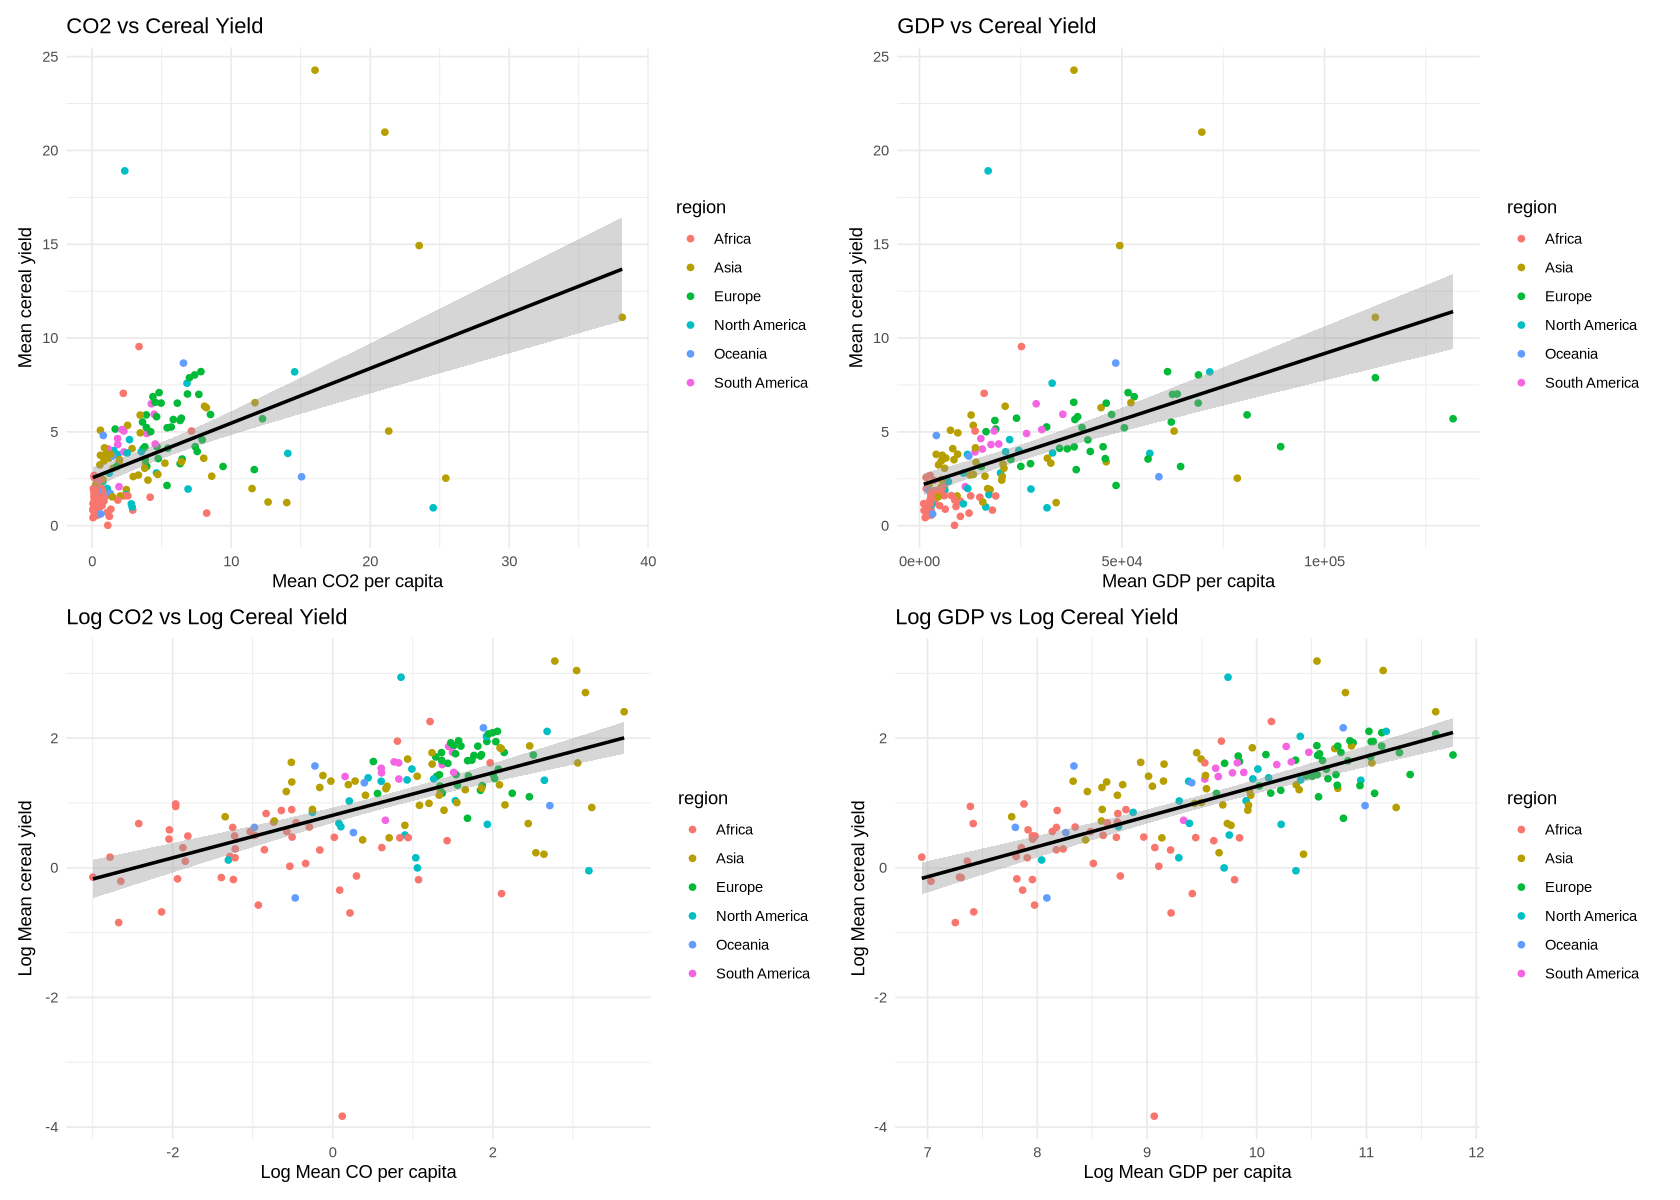

In [137]:
options(repr.plot.width = 14, repr.plot.height = 10)
plot1 <- ggplot(model_df, aes(x = mean_co, y = mean_yield, color = region)) +
  geom_point() + geom_smooth(method = "lm", se = TRUE, color = "black") + 
  labs(x = "Mean CO2 per capita", y = "Mean cereal yield", title = "CO2 vs Cereal Yield") + theme_minimal()

plot2 <- ggplot(model_df, aes(x = mean_gdp, y = mean_yield, color = region)) +
  geom_point() + geom_smooth(method = "lm", se = TRUE, color = "black") + 
  labs(x = "Mean GDP per capita", y = "Mean cereal yield", title = "GDP vs Cereal Yield") + theme_minimal()

plot3 <- ggplot(model_df, aes(x = log(mean_co), y = log(mean_yield), color = region)) +
  geom_point() + geom_smooth(method = "lm", se = TRUE, color = "black") + 
  labs(x = "Log Mean CO per capita", y = "Log Mean cereal yield", title = "Log CO2 vs Log Cereal Yield") + theme_minimal()

plot4 <- ggplot(model_df, aes(x = log(mean_gdp), y = log(mean_yield), color = region)) +
  geom_point() + geom_smooth(method = "lm", se = TRUE, color = "black") + 
  labs(x = "Log Mean GDP per capita", y = "Log Mean cereal yield", title = "Log GDP vs Log Cereal Yield") + theme_minimal()
(plot1 + plot2) / (plot3 + plot4)

In [132]:
model_df_log <- model_df %>% mutate (log_mean_yield = log(mean_yield), log_mean_gdp = log(mean_gdp), log_mean_co = log(mean_co))
fit <- lm(log_mean_yield ~ log_mean_co + log_mean_gdp, data = model_df_log)
summary(fit)


Call:
lm(formula = log_mean_yield ~ log_mean_co + log_mean_gdp, data = model_df_log)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.6570 -0.2997  0.0446  0.3259  1.8001 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -4.08889    0.97715  -4.185 4.61e-05 ***
log_mean_co  -0.06864    0.08663  -0.792    0.429    
log_mean_gdp  0.54292    0.10810   5.022 1.30e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.6587 on 167 degrees of freedom
Multiple R-squared:  0.3973,	Adjusted R-squared:   0.39 
F-statistic: 55.03 on 2 and 167 DF,  p-value: < 2.2e-16


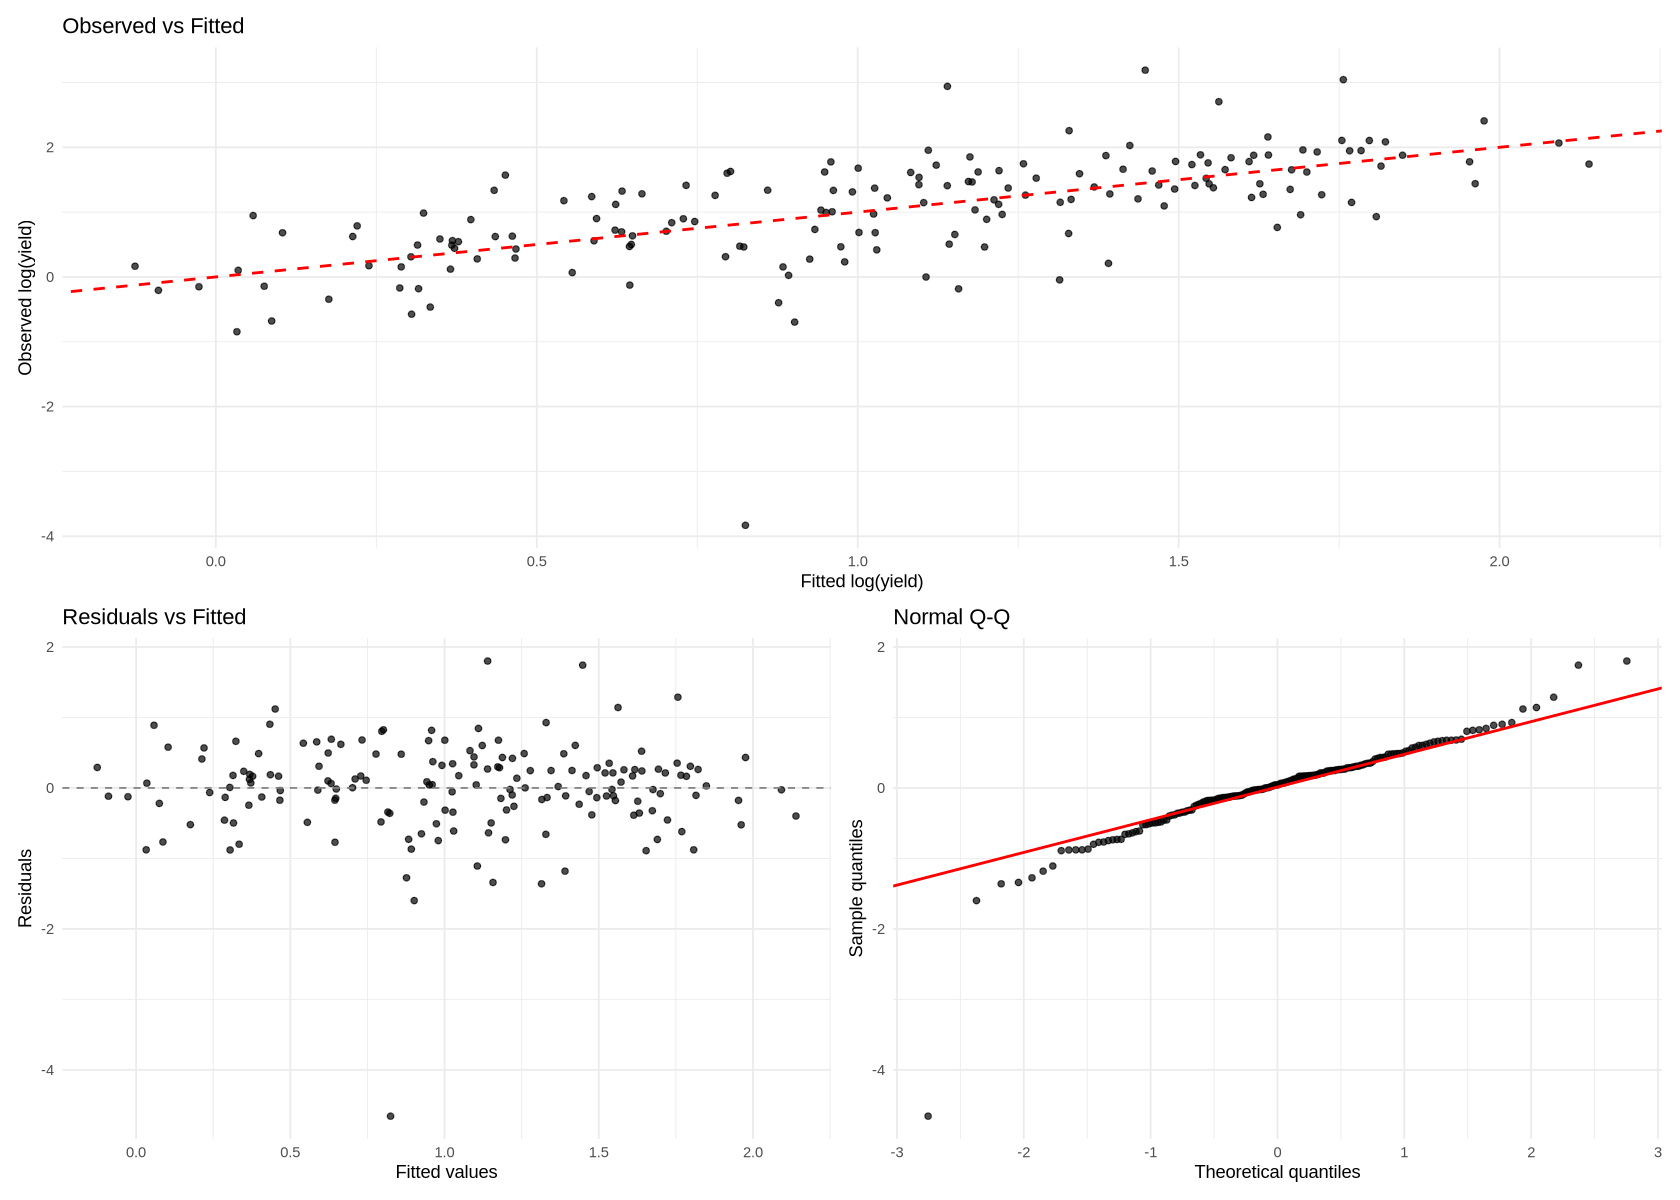

In [138]:
options(repr.plot.width = 14, repr.plot.height = 10)
plot5 <- ggplot(data.frame(fitted   = fitted(fit),
                        observed = model_df_log$log_mean_yield),
             aes(x = fitted, y = observed)) +
  geom_point(alpha = 0.7) +
  geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed", linewidth = 0.8) +
  labs(x = "Fitted log(yield)", y = "Observed log(yield)", title = "Observed vs Fitted") +
  theme_minimal()

plot6 <- ggplot(data.frame(fitted = fitted(fit),
                        resid  = resid(fit)),
             aes(x = fitted, y = resid)) +
  geom_point(alpha = 0.7) +
  geom_hline(yintercept = 0, color = "grey50", linetype = "dashed") +
  labs(x = "Fitted values", y = "Residuals", title = "Residuals vs Fitted") +
  theme_minimal()

plot7 <- ggplot(data.frame(resid = resid(fit)), aes(sample = resid)) +
  stat_qq(alpha = 0.7) +
  stat_qq_line(color = "red", linewidth = 0.8) +
  labs(x = "Theoretical quantiles", y = "Sample quantiles", title = "Normal Q-Q") +
  theme_minimal()

plot5 / (plot6 + plot7)


In [129]:
#Determine outlier:
outlier <- model_df_log %>% filter(log_mean_yield == min(model_df_log$log_mean_yield)) %>% select(Entity)
outlier 

Entity
<chr>
Cape Verde


In [130]:
#Remove from Dataset:
model_df_log_no_cape_verde <- model_df_log %>% filter(log_mean_yield != min(model_df_log$log_mean_yield))

# Refitting without outlier:
fit2 <- lm(log_mean_yield ~ log_mean_co + log_mean_gdp, data = model_df_log_no_cape_verde)
summary(fit2)


Call:
lm(formula = log_mean_yield ~ log_mean_co + log_mean_gdp, data = model_df_log_no_cape_verde)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.62949 -0.28877  0.01813  0.29747  1.77434 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -4.00510    0.81923  -4.889 2.38e-06 ***
log_mean_co  -0.07226    0.07262  -0.995    0.321    
log_mean_gdp  0.53727    0.09063   5.928 1.72e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.5522 on 166 degrees of freedom
Multiple R-squared:  0.4749,	Adjusted R-squared:  0.4685 
F-statistic: 75.05 on 2 and 166 DF,  p-value: < 2.2e-16



Call:
lm(formula = log_mean_yield ~ log_mean_co + log_mean_gdp, data = model_df_log_no_cape_verde)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.62949 -0.28877  0.01813  0.29747  1.77434 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -4.00510    0.81923  -4.889 2.38e-06 ***
log_mean_co  -0.07226    0.07262  -0.995    0.321    
log_mean_gdp  0.53727    0.09063   5.928 1.72e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.5522 on 166 degrees of freedom
Multiple R-squared:  0.4749,	Adjusted R-squared:  0.4685 
F-statistic: 75.05 on 2 and 166 DF,  p-value: < 2.2e-16


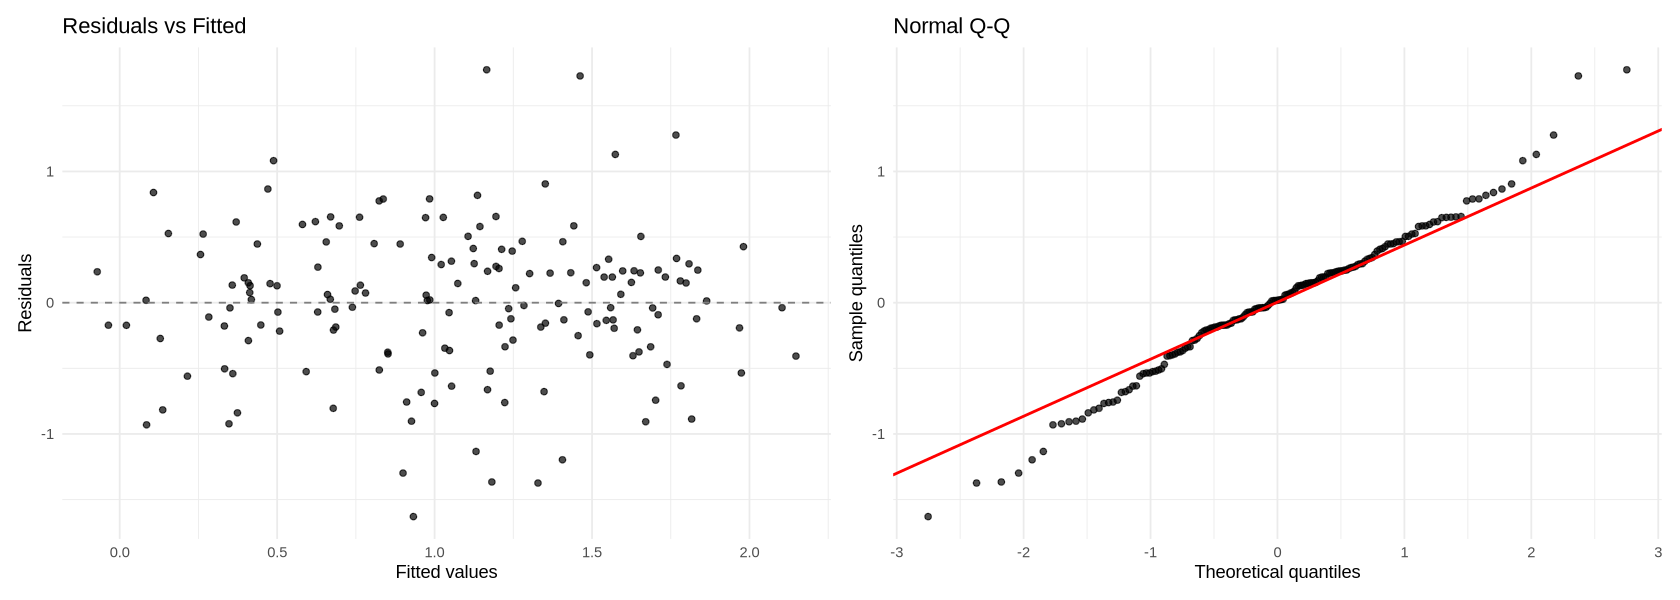

In [140]:
# Visualizing after removing the outlier:
options(repr.plot.width = 14, repr.plot.height = 5)
# Residuals vs Fitted
plot8 <- ggplot(data.frame(fitted = fitted(fit2), resid = resid(fit2)),
             aes(x = fitted, y = resid)) +
  geom_point(alpha = 0.7) +
  geom_hline(yintercept = 0, color = "grey50", linetype = "dashed") +
  labs(x = "Fitted values", y = "Residuals", title = "Residuals vs Fitted") +
  theme_minimal()

# Normal Q-Q
plot9 <- ggplot(data.frame(resid = resid(fit2)), aes(sample = resid)) +
  stat_qq(alpha = 0.7) +
  stat_qq_line(color = "red", linewidth = 0.8) +
  labs(x = "Theoretical quantiles", y = "Sample quantiles", title = "Normal Q-Q") +
  theme_minimal()

plot8 + plot9

summary(fit2)